# Лабораторная 6 — Сегментация дорожных знаков

## 1. Импорты и настройка

In [1]:
import os, random, json, zipfile, time, shutil, glob
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


Device: cuda
PyTorch: 2.9.0+cu128
GPU: NVIDIA GeForce RTX 3050


## 2. Установка зависимостей

In [2]:
%pip install -q ultralytics kaggle

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3. Скачивание датасета Russian Road Signs (segmentation)

In [3]:
SIGN_DIR  = Path('DATA/RoadSigns/sign_dataset')
TRAIN_DIR = SIGN_DIR / 'train'
VAL_DIR   = SIGN_DIR / 'val'

if TRAIN_DIR.exists() and VAL_DIR.exists() and any(TRAIN_DIR.glob('*.jpg')):
    n_tr = len(list(TRAIN_DIR.glob('*.jpg')))
    n_va = len(list(VAL_DIR.glob('*.jpg')))
    print(f'Датасет уже распакован: {SIGN_DIR.resolve()}')
    print(f'  train: {n_tr} изображений')
    print(f'  val:   {n_va} изображений')
else:
    print('Скачиваем viacheslavshalamov/russian-road-signs-segmentation-dataset...')
    SIGN_DIR.parent.mkdir(parents=True, exist_ok=True)
    from kaggle.api.kaggle_api_extended import KaggleApi
    api = KaggleApi(); api.authenticate()
    t0 = time.time()
    api.dataset_download_files(
        'viacheslavshalamov/russian-road-signs-segmentation-dataset',
        path=str(SIGN_DIR.parent),
        unzip=True,
        quiet=False,
    )
    print(f'Готово за {time.time()-t0:.0f} с')


Датасет уже распакован: C:\Users\valer\OneDrive\Рабочий стол\CV_ITMO\DATA\RoadSigns\sign_dataset
  train: 2054 изображений
  val:   127 изображений


## 4. Разведка данных: VIA-разметка (полигоны знаков)

In [8]:
from collections import Counter

# Датасет содержит только 1 класс — "road sign".
# Поэтому учим 1-классовую сегментацию.
CLASS_NAMES = ['road_sign']
ID_MAP = {'road_sign': 0}  

def load_via_split(split_dir):
    """Парсим via_region_data.json в директории.
    Возвращает dict: filename(.jpg) -> list of {'class_id': 0, 'polygon': [(x,y), ...]}"""
    via_path = split_dir / 'via_region_data.json'
    with open(via_path, encoding='utf-8') as f:
        via = json.load(f)
    by_image = {}
    for entry in via.values():
        fn = entry['filename']
        items = []
        regions = entry.get('regions', {})
        if isinstance(regions, dict):
            regions = regions.values()
        for r in regions:
            shape = r.get('shape_attributes', {})
            if shape.get('name') != 'polygon':
                continue
            xs = shape.get('all_points_x', [])
            ys = shape.get('all_points_y', [])
            if len(xs) < 3 or len(xs) != len(ys):
                continue
            polygon = list(zip(xs, ys))
            items.append({'class_id': 0, 'polygon': polygon})
        if items:
            by_image[fn] = items
    return by_image

train_by_image = load_via_split(TRAIN_DIR)
val_by_image   = load_via_split(VAL_DIR)

train_imgs = sorted(train_by_image.keys())
val_imgs   = sorted(val_by_image.keys())

print(f'train: {len(train_imgs)} изображений с разметкой, '
      f'{sum(len(v) for v in train_by_image.values())} полигонов')
print(f'val:   {len(val_imgs)} изображений с разметкой, '
      f'{sum(len(v) for v in val_by_image.values())} полигонов')
print(f'\nКласс(ы): {CLASS_NAMES}')


train: 1905 изображений с разметкой, 4426 полигонов
val:   117 изображений с разметкой, 312 полигонов

Класс(ы): ['road_sign']


## 5. Визуализация образцов

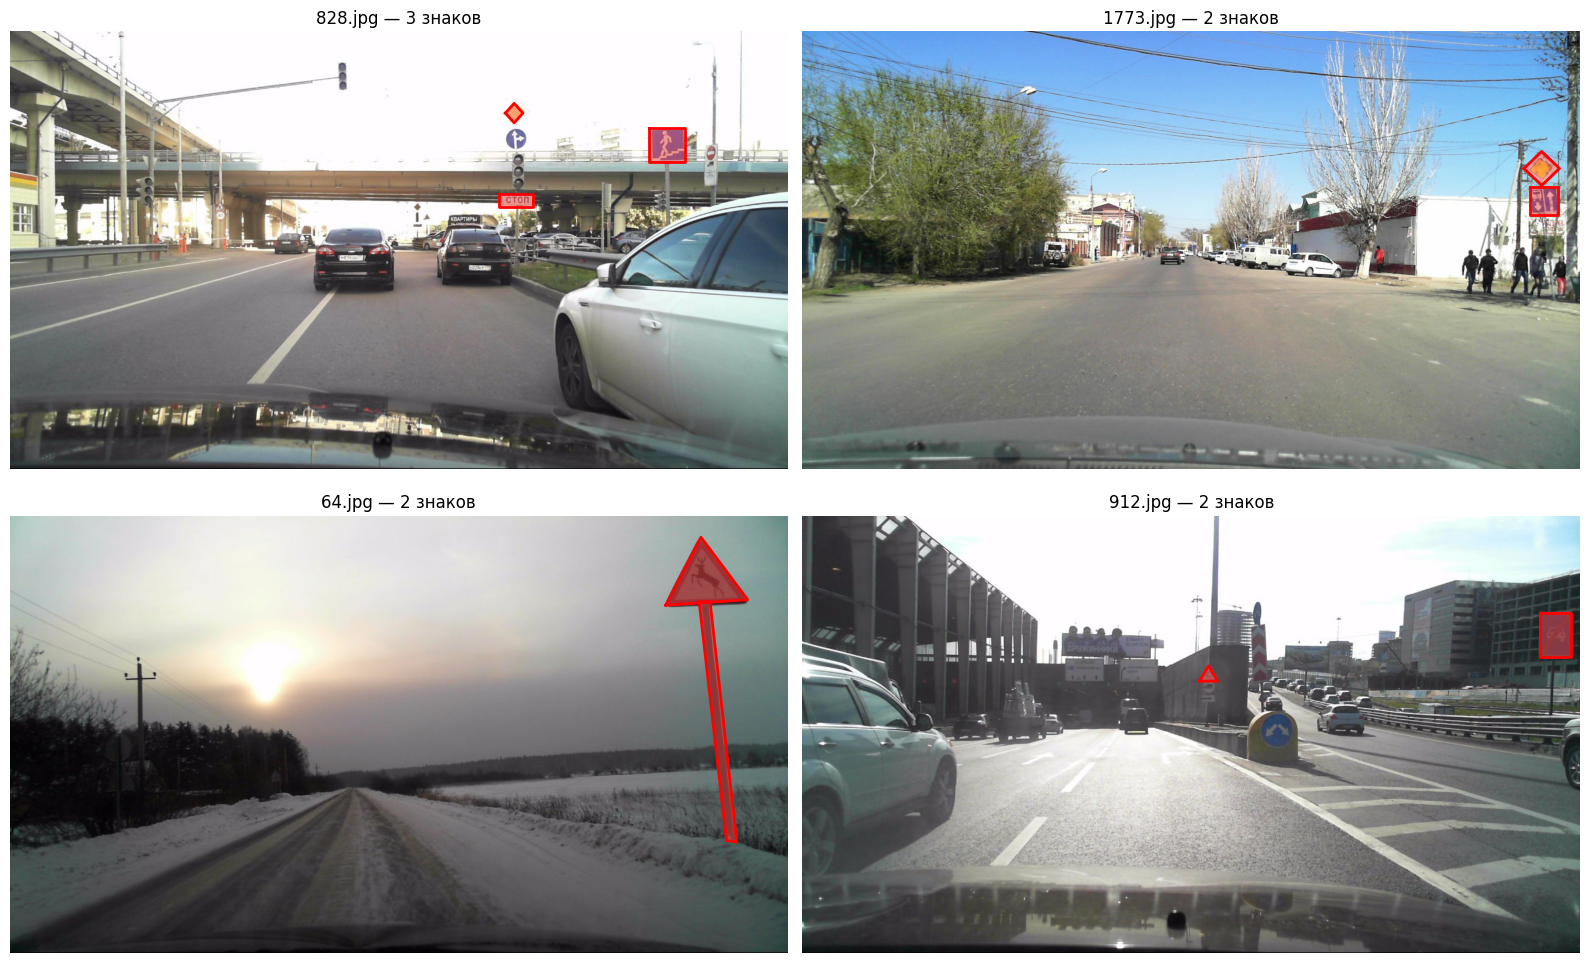

In [ ]:
def rasterize_polygon_full(polygon, H, W):
    from PIL import ImageDraw
    canvas = Image.new('L', (W, H), 0)
    if len(polygon) >= 3:
        ImageDraw.Draw(canvas).polygon([tuple(map(float, p)) for p in polygon], fill=1)
    return np.array(canvas, dtype=bool)


def show_sample(filename, items, base_dir, ax=None):
    img = np.array(Image.open(base_dir / filename).convert('RGB'))
    H, W = img.shape[:2]
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 7))
    overlay = img.copy().astype(np.float32)
    color = np.array([255, 80, 80], dtype=np.float32)

    for it in items:
        mask = rasterize_polygon_full(it['polygon'], H, W)
        overlay[mask] = 0.5 * overlay[mask] + 0.5 * color
        xs = [p[0] for p in it['polygon']]
        ys = [p[1] for p in it['polygon']]
        ax.plot(xs + [xs[0]], ys + [ys[0]], color='red', linewidth=2)

    ax.imshow(overlay.astype(np.uint8))
    ax.set_title(f'{filename} — {len(items)} знаков')
    ax.axis('off')


random.seed(0)
samples = random.sample(train_imgs, 4)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, fn in zip(axes.flat, samples):
    show_sample(fn, train_by_image[fn], TRAIN_DIR, ax)
plt.tight_layout()
plt.show()


## 6. Конвертация VIA-полигонов -> YOLO-seg формат

In [10]:
YOLO_DIR = Path('DATA/yolo_roadsigns')
for split in ('train', 'val'):
    (YOLO_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)


def polygon_to_yolo(polygon, img_w, img_h):
    coords = []
    for x, y in polygon:
        coords.append(min(max(x / img_w, 0.0), 1.0))
        coords.append(min(max(y / img_h, 0.0), 1.0))
    return coords


def convert_split(by_image, base_dir, split):
    n_imgs = n_polys = 0
    for fn, items in by_image.items():
        src = base_dir / fn
        if not src.exists():
            continue
        dst = YOLO_DIR / 'images' / split / fn
        if not dst.exists():
            shutil.copy2(src, dst)
        with Image.open(src) as im:
            W, H = im.size
        lines = []
        for it in items:
            poly = polygon_to_yolo(it['polygon'], W, H)
            if len(poly) < 6:  
                continue
            lines.append(f"{it['class_id']} " + ' '.join(f'{v:.6f}' for v in poly))
            n_polys += 1
        label_path = YOLO_DIR / 'labels' / split / (Path(fn).stem + '.txt')
        label_path.write_text('\n'.join(lines))
        n_imgs += 1
    return n_imgs, n_polys


t0 = time.time()
n_tr, p_tr = convert_split(train_by_image, TRAIN_DIR, 'train')
n_va, p_va = convert_split(val_by_image,   VAL_DIR,   'val')
print(f'Сконвертировано за {time.time() - t0:.1f} с')
print(f'  train: {n_tr} изображений, {p_tr} полигонов')
print(f'  val:   {n_va} изображений, {p_va} полигонов')

sample_label = next((YOLO_DIR / 'labels' / 'train').glob('*.txt'))
print(f'\nПример {sample_label.name}:')
print(sample_label.read_text()[:300])


Сконвертировано за 70.4 с
  train: 1905 изображений, 4426 полигонов
  val:   117 изображений, 312 полигонов

Пример 1.txt:
0 0.732031 0.297222 0.780469 0.287500 0.789062 0.376389 0.739844 0.384722 0.732031 0.297222
0 0.519531 0.537500 0.526563 0.506944 0.536719 0.536111 0.519531 0.537500
0 0.518750 0.548611 0.534375 0.547222 0.535156 0.561111 0.519531 0.562500 0.518750 0.548611
0 0.782031 0.654167 0.760938 0.381944 0.76


## 7. `data.yaml` для YOLO

In [11]:
YAML_PATH = YOLO_DIR / 'data.yaml'

yaml_text = (
    f'path: {YOLO_DIR.resolve().as_posix()}\n'
    f'train: images/train\n'
    f'val:   images/val\n'
    f'nc: {len(CLASS_NAMES)}\n'
    f'names: {CLASS_NAMES}\n'
)
YAML_PATH.write_text(yaml_text, encoding='utf-8')

print(f'Записан конфиг: {YAML_PATH}')
print('---')
print(yaml_text)


Записан конфиг: DATA\yolo_roadsigns\data.yaml
---
path: C:/Users/valer/OneDrive/Рабочий стол/CV_ITMO/DATA/yolo_roadsigns
train: images/train
val:   images/val
nc: 1
names: ['road_sign']



## 8. Обучение YOLOv8n-seg

In [12]:
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')

t0 = time.time()
results = model.train(
    data=str(YAML_PATH),
    epochs=10,
    imgsz=640,
    batch=16,
    patience=5,
    workers=0,
    device=0,
    name='roadsigns-seg',
    project='runs/segment',
    seed=42,
    exist_ok=True,
)
print(f'\nОбучение завершено за {(time.time() - t0)/60:.1f} мин')

RUN_DIR = Path(results.save_dir)
BEST_WEIGHTS = RUN_DIR / 'weights' / 'best.pt'
print(f'Run dir: {RUN_DIR}')
print(f'Best weights: {BEST_WEIGHTS}')


New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.47  Python-3.13.1 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=DATA\yolo_roadsigns\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0

## 9. Графики обучения и встроенная валидация YOLO

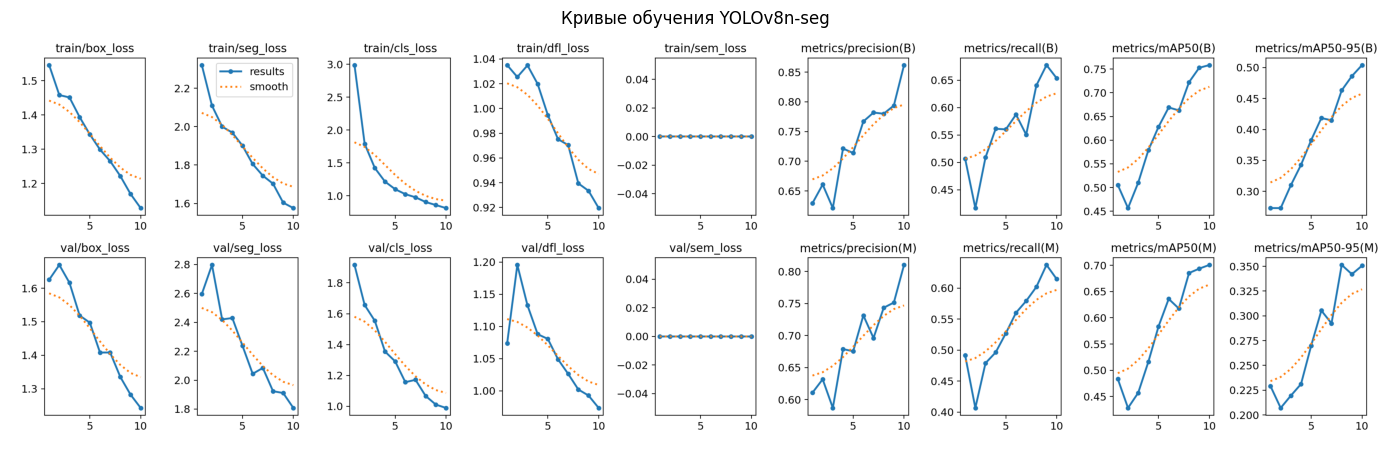

Ultralytics 8.4.47  Python-3.13.1 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050, 8192MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1088.8871.6 MB/s, size: 1159.2 KB)
val: Scanning C:\Users\valer\OneDrive\Рабочий стол\CV_ITMO\DATA\yolo_roadsigns\labels\val.cache... 126 images, 0 backgrounds, 6 corrupt: 100% ━━━━━━━━━━━━ 126/126 33.0Mit/s 0.0s
val: C:\Users\valer\OneDrive\ \CV_ITMO\DATA\yolo_roadsigns\images\val\207.jpg: corrupt JPEG restored and saved
val: C:\Users\valer\OneDrive\ \CV_ITMO\DATA\yolo_roadsigns\images\val\2086.jpg: ignoring corrupt image/label: Label class 4 exceeds dataset class count 1. Possible class labels are 0-0
val: C:\Users\valer\OneDrive\ \CV_ITMO\DATA\yolo_roadsigns\images\val\211.jpg: corrupt JPEG restored and saved
val: C:\Users\valer\OneDrive\ \CV_ITMO\DATA\yolo_roadsigns\images\val\2123.jpg: ignoring corrupt image/label: Label class 2 exceeds dataset class count

In [13]:
results_png = RUN_DIR / 'results.png'
if results_png.exists():
    img = Image.open(results_png)
    plt.figure(figsize=(14, 7))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Кривые обучения YOLOv8n-seg')
    plt.tight_layout()
    plt.show()

best_model = YOLO(str(BEST_WEIGHTS))
val_metrics = best_model.val(
    data=str(YAML_PATH),
    imgsz=640,
    batch=8,
    workers=0,
    device=0,
    verbose=False,
    plots=False,
)

print('Встроенные метрики YOLO на val:')
print(f"  Box  mAP@0.5     : {val_metrics.box.map50:.4f}")
print(f"  Box  mAP@0.5:0.95: {val_metrics.box.map:.4f}")
print(f"  Mask mAP@0.5     : {val_metrics.seg.map50:.4f}")
print(f"  Mask mAP@0.5:0.95: {val_metrics.seg.map:.4f}")

## 10. Кастомные метрики: IoU, Precision, Recall, L2 + проценты по порогам

In [14]:
from PIL import ImageDraw


def rasterize_polygon(poly_xy, h, w):
    canvas = Image.new('L', (w, h), 0)
    if len(poly_xy) >= 3:
        ImageDraw.Draw(canvas).polygon([tuple(map(float, p)) for p in poly_xy], fill=1)
    return np.array(canvas, dtype=bool)


def mask_iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 0.0


def mask_l2(a, b):
    diff = a.astype(np.float32) - b.astype(np.float32)
    return float(np.sqrt(np.mean(diff ** 2)))


def evaluate(model, image_paths, gt_by_image, iou_thresh=0.5, conf=0.25):
    tp = fp = fn_ = 0
    matched_ious = []
    matched_l2s = []
    all_gt_best_ious = []

    for img_path in image_paths:
        fname = Path(img_path).name
        gt_list = gt_by_image.get(fname, [])
        with Image.open(img_path) as im:
            W, H = im.size

        gt_masks = [rasterize_polygon(g['polygon'], H, W) for g in gt_list]

        result = model.predict(str(img_path), conf=conf, imgsz=640, device=0, verbose=False)[0]
        pred_masks = []
        if result.masks is not None and len(result.masks) > 0:
            for poly in result.masks.xy:
                pred_masks.append(rasterize_polygon(poly, H, W))

        used_pred = set()
        per_gt_iou = [0.0] * len(gt_masks)

        for gi, gm in enumerate(gt_masks):
            best_iou = 0.0
            best_pi = -1
            for pi, pm in enumerate(pred_masks):
                if pi in used_pred:
                    continue
                iou = mask_iou(gm, pm)
                if iou > best_iou:
                    best_iou = iou
                    best_pi = pi
            per_gt_iou[gi] = best_iou
            if best_iou >= iou_thresh and best_pi >= 0:
                used_pred.add(best_pi)
                tp += 1
                matched_ious.append(best_iou)
                matched_l2s.append(mask_l2(gt_masks[gi], pred_masks[best_pi]))
            else:
                fn_ += 1

        fp += len(pred_masks) - len(used_pred)
        all_gt_best_ious.extend(per_gt_iou)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn_) if (tp + fn_) > 0 else 0.0
    mean_iou  = float(np.mean(matched_ious)) if matched_ious else 0.0
    mean_l2   = float(np.mean(matched_l2s))  if matched_l2s  else 0.0

    all_ious = np.asarray(all_gt_best_ious, dtype=float)
    pct = {f'IoU>={t}': (float((all_ious >= t).mean()) * 100 if len(all_ious) else 0.0)
           for t in (0.5, 0.75, 0.9)}

    return {
        'precision': precision, 'recall': recall,
        'mean_iou': mean_iou,   'mean_l2': mean_l2,
        'tp': tp, 'fp': fp, 'fn': fn_,
        'pct': pct, 'n_gt': int(len(all_ious)),
    }


val_image_paths = sorted((YOLO_DIR / 'images' / 'val').glob('*.jpg'))
print(f'Оценка на {len(val_image_paths)} val-изображениях...')

t0 = time.time()
val_results = evaluate(best_model, val_image_paths, val_by_image, iou_thresh=0.5, conf=0.25)
print(f'Готово за {time.time() - t0:.1f} с\n')

print(f"=== VAL ({val_results['n_gt']} GT-объектов) ===")
print(f"  Precision : {val_results['precision']:.4f}")
print(f"  Recall    : {val_results['recall']:.4f}")
print(f"  Mean IoU  : {val_results['mean_iou']:.4f}")
print(f"  Mean L2   : {val_results['mean_l2']:.4f}")
print(f"  TP={val_results['tp']}, FP={val_results['fp']}, FN={val_results['fn']}")
for k, v in val_results['pct'].items():
    print(f"  % {k:8s}: {v:.1f}%")


Оценка на 126 val-изображениях...
Готово за 14.2 с

=== VAL (312 GT-объектов) ===
  Precision : 0.8231
  Recall    : 0.6859
  Mean IoU  : 0.7286
  Mean L2   : 0.0259
  TP=214, FP=46, FN=98
  % IoU>=0.5: 68.6%
  % IoU>=0.75: 29.8%
  % IoU>=0.9: 4.5%


## 11. Визуализация предсказаний на val

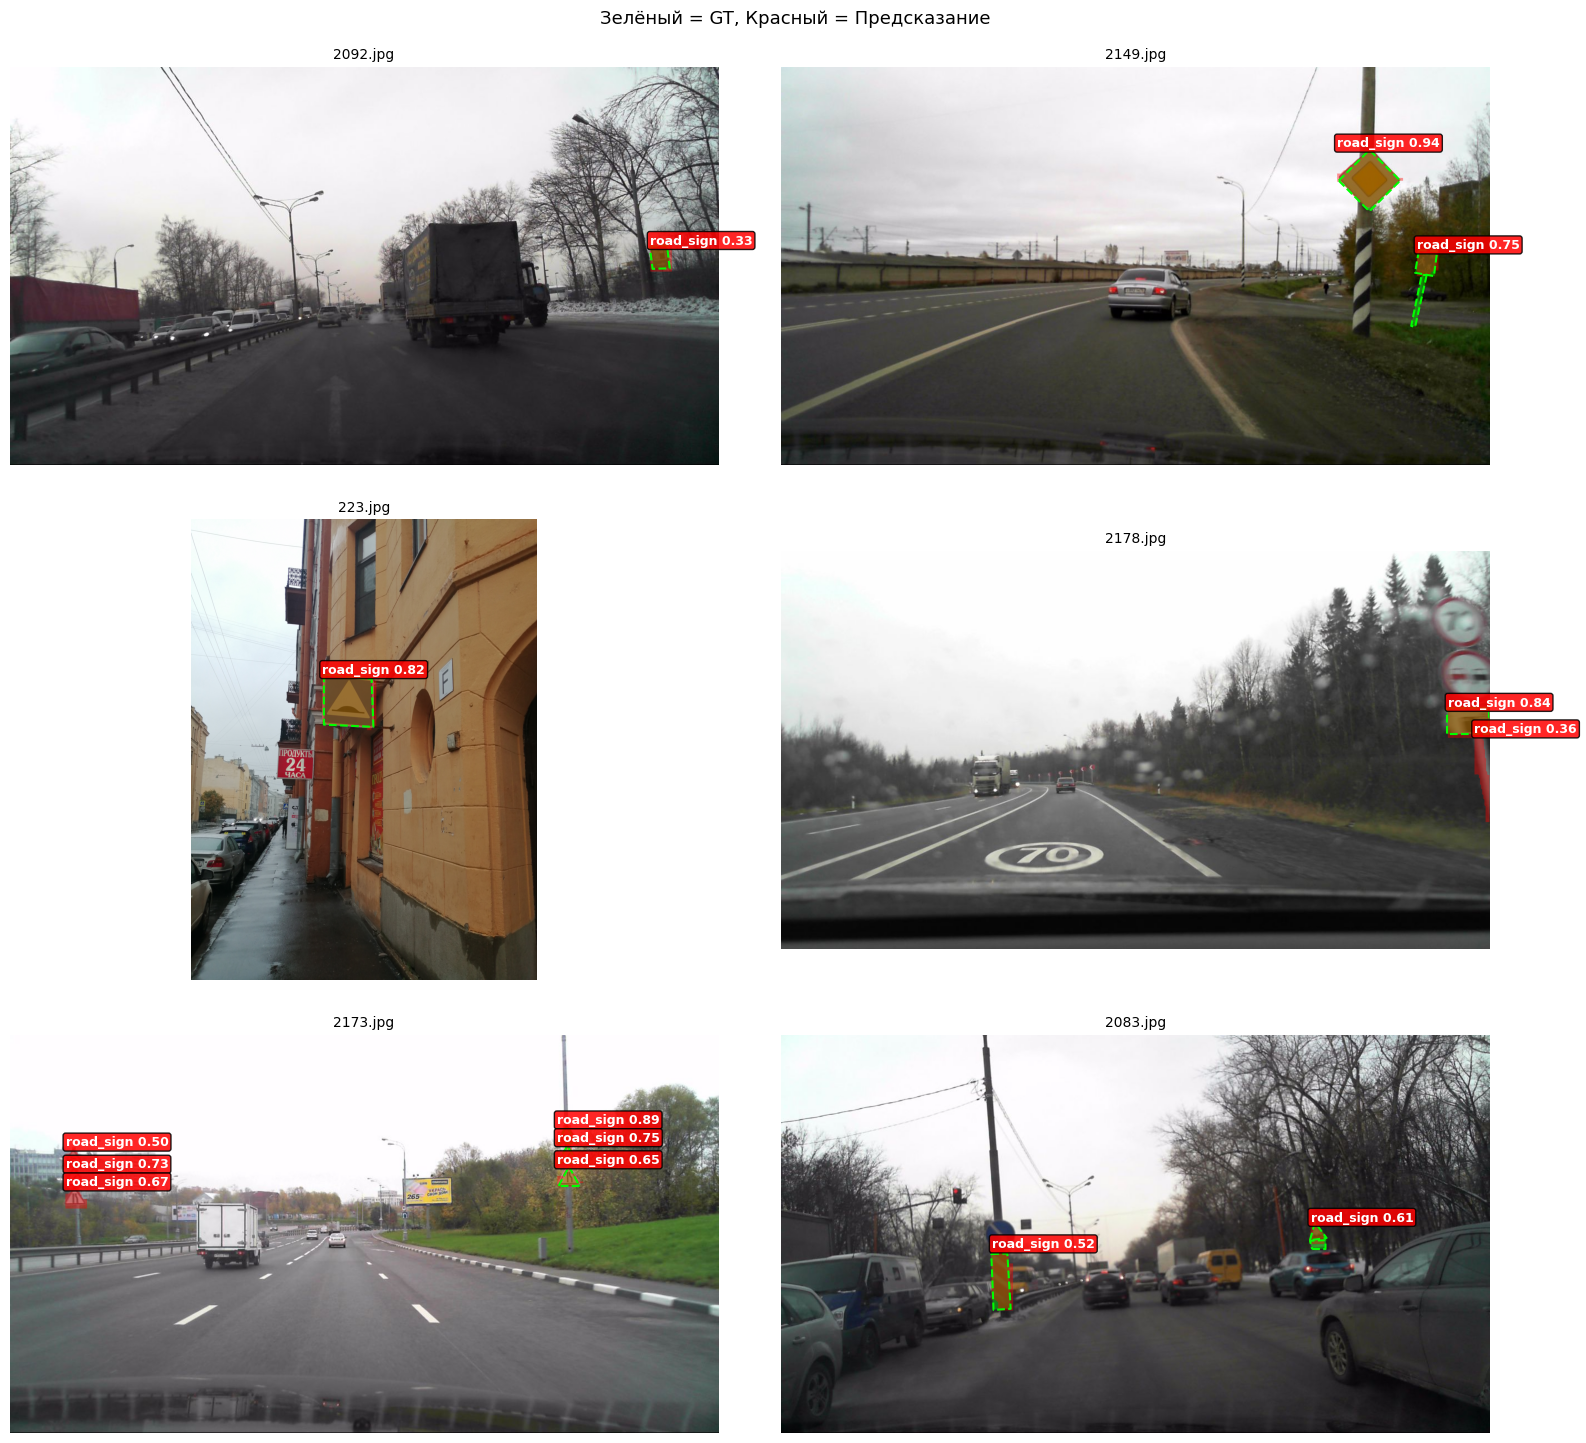

In [15]:
def show_predictions(model, img_paths, gt_by_image, n_show=6, conf=0.25):
    n_show = min(n_show, len(img_paths))
    cols = 2
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
    axes = axes.flat if rows * cols > 1 else [axes]

    for ax, img_path in zip(axes, img_paths[:n_show]):
        img = np.array(Image.open(img_path).convert('RGB'))
        H, W = img.shape[:2]
        overlay = img.copy().astype(np.float32)

        for g in gt_by_image.get(Path(img_path).name, []):
            m = rasterize_polygon(g['polygon'], H, W)
            overlay[m] = 0.6 * overlay[m] + 0.4 * np.array([0, 255, 0])
            xs = [p[0] for p in g['polygon']]
            ys = [p[1] for p in g['polygon']]
            ax.plot(xs + [xs[0]], ys + [ys[0]],
                    color='lime', linewidth=1.5, linestyle='--')

        result = model.predict(str(img_path), conf=conf, imgsz=640, device=0, verbose=False)[0]
        if result.masks is not None and len(result.masks) > 0:
            for poly, cls, sc in zip(
                result.masks.xy,
                result.boxes.cls.cpu().numpy().astype(int),
                result.boxes.conf.cpu().numpy(),
            ):
                m = rasterize_polygon(poly, H, W)
                overlay[m] = 0.6 * overlay[m] + 0.4 * np.array([255, 0, 0])
                if len(poly) >= 1:
                    px, py = float(poly[:, 0].min()), float(poly[:, 1].min())
                    ax.text(px, max(0, py - 4),
                            f'{CLASS_NAMES[cls]} {sc:.2f}',
                            color='white', fontsize=9, fontweight='bold',
                            bbox=dict(boxstyle='round,pad=0.2', facecolor='red', alpha=0.85))

        ax.imshow(overlay.astype(np.uint8))
        ax.set_title(Path(img_path).name, fontsize=10)
        ax.axis('off')

    plt.suptitle('Зелёный = GT, Красный = Предсказание', fontsize=13)
    plt.tight_layout()
    plt.show()


random.seed(1)
val_with_gt = [p for p in val_image_paths if val_by_image.get(p.name)]
samples = random.sample(val_with_gt, min(6, len(val_with_gt)))
show_predictions(best_model, samples, val_by_image, n_show=6, conf=0.25)


## 12. Тест на собственных фотографиях

In [16]:
CUSTOM_DIR = Path('DATA/RoadSigns/custom')
CUSTOM_DIR.mkdir(parents=True, exist_ok=True)

custom_imgs = sorted([p for p in CUSTOM_DIR.iterdir()
                      if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])

print(f'Найдено фотографий: {len(custom_imgs)}')
print(f'Папка: {CUSTOM_DIR.resolve()}\n')

if not custom_imgs:
    print('Положите фото в эту папку и перезапустите ячейку.')
else:
    show_predictions(best_model, custom_imgs, {},
                     n_show=min(len(custom_imgs), 10), conf=0.25)

    total_dets = 0
    for img_path in custom_imgs:
        r = best_model.predict(str(img_path), conf=0.25, imgsz=640,
                               device=0, verbose=False)[0]
        n = 0 if r.masks is None else len(r.masks)
        total_dets += n
        print(f'  {img_path.name}: {n} детекций')
    print(f'\nИтого детекций на {len(custom_imgs)} фото: {total_dets}')


Найдено фотографий: 0
Папка: C:\Users\valer\OneDrive\Рабочий стол\CV_ITMO\DATA\RoadSigns\custom

Положите фото в эту папку и перезапустите ячейку.
